In [4]:
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer, RobertaModel, get_linear_schedule_with_warmup
from torch.optim import AdamW 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, matthews_corrcoef
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

## Configurations

In [5]:
class Config:
    MAX_LEN = 256
    TRAIN_BATCH_SIZE = 16
    VALID_BATCH_SIZE = 16
    EPOCHS = 5
    LEARNING_RATE = 2e-5
    NUM_CLASSES = 4
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    DATA_PATH = "promise19_dataset.csv"
    TEST_SIZE = 0.2
    RANDOM_STATE = 42
    
    FOCAL_LOSS_GAMMA = 3.0 
    ROBERTA_MODEL = 'roberta-base'

SEVERITY_MAP = {
    'SEVERE': 0, # Blocker, Critical, Urgent
    'HIGH': 1,   # Major
    'MEDIUM': 2, # Normal, Medium
    'LOW': 3     # Minor, Low, Trivial
}

def map_severity(label):
    """Maps Priority strings to integer target labels."""
    if not isinstance(label, str): return SEVERITY_MAP['MEDIUM']
    label = label.lower()
    if label in ['blocker', 'critical', 'urgent']: return SEVERITY_MAP['SEVERE']
    elif label in ['major']: return SEVERITY_MAP['HIGH']
    elif label in ['normal', 'medium']: return SEVERITY_MAP['MEDIUM']
    elif label in ['minor', 'low', 'trivial']: return SEVERITY_MAP['LOW']
    return SEVERITY_MAP['HIGH'] 

class BugDataset(Dataset):
    def __init__(self, texts, metrics, targets, tokenizer, max_len):
        self.texts = texts
        self.metrics = metrics
        self.targets = targets
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        metric = self.metrics[item]
        target = self.targets[item]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'metrics': torch.tensor(metric, dtype=torch.float),
            'targets': torch.tensor(target, dtype=torch.long)
        }

# Model Arch
class HybridRoBERTa(nn.Module):
    """Combines RoBERTa text features with numerical metrics via an MLP."""
    def __init__(self, num_metrics, num_classes):
        super(HybridRoBERTa, self).__init__()
        self.roberta = RobertaModel.from_pretrained(Config.ROBERTA_MODEL)
        self.drop_text = nn.Dropout(0.3)
        
        self.mlp = nn.Sequential(
            nn.Linear(num_metrics, 64),
            nn.BatchNorm1d(64), 
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(768 + 32, 128), 
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, input_ids, attention_mask, metrics):
        roberta_output = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        text_features = self.drop_text(roberta_output.pooler_output)
        metric_features = self.mlp(metrics)
        combined = torch.cat((text_features, metric_features), dim=1)
        return self.classifier(combined)

# Focal Loss
class FocalLoss(nn.Module):
    """Focal Loss with only gamma for balancing (avoids aggressive alpha)."""
    def __init__(self, gamma=3.0):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=None, reduction='none') 

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt = torch.exp(-ce_loss)
        return ((1 - pt) ** self.gamma * ce_loss).mean()

# Training and Eval
def train_epoch(model, loader, loss_fn, optimizer, scheduler, device):
    model.train()
    losses, correct = [], 0
    for d in loader:
        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)
        metrics = d["metrics"].to(device)
        targets = d["targets"].to(device)

        outputs = model(input_ids, attention_mask, metrics)
        loss = loss_fn(outputs, targets)
        
        _, preds = torch.max(outputs, dim=1)
        correct += torch.sum(preds == targets)
        losses.append(loss.item())

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        
    return correct.double() / len(loader.dataset), np.mean(losses)

def eval_model(model, loader, loss_fn, device):
    model.eval()
    losses, correct = [], 0
    preds_list, targets_list = [], []
    
    with torch.no_grad():
        for d in loader:
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            metrics = d["metrics"].to(device)
            targets = d["targets"].to(device)

            outputs = model(input_ids, attention_mask, metrics)
            loss = loss_fn(outputs, targets)
            
            _, preds = torch.max(outputs, dim=1)
            correct += torch.sum(preds == targets)
            losses.append(loss.item())
            
            preds_list.extend(preds.cpu().numpy())
            targets_list.extend(targets.cpu().numpy())
            
    return correct.double() / len(loader.dataset), np.mean(losses), preds_list, targets_list

train_losses_history = []
val_losses_history = []

## Data importing

In [6]:
print(f"Using device: {Config.DEVICE}")
    
print("Data Importing and Cleaning...")
df = pd.read_csv(Config.DATA_PATH)
df = df.dropna(subset=['Priority']).copy()
df['target'] = df['Priority'].apply(map_severity)

metric_cols = [
    'NoComments', 'NoWatchers', 'NoAttachments', 'NoAttachedPatches', 
    'HasMergeCommit', 'NoCommits', 'NoAuthors', 'SrcAddFiles', 
    'SrcModFiles', 'SrcDelFiles', 'SrcAddLines', 'SrcDelLines', 
    'TestAddLines', 'TestDelLines', 'LoC',
]

Using device: cuda
Data Importing and Cleaning...


## Feature Engineering

In [7]:
print("Feature Engineering...")
    
text_cols = ['SummaryTopWords', 'DescriptionTopWords', 'CommentsTopWords']
df[text_cols] = df[text_cols].fillna("") 
df['CombinedText'] = df['SummaryTopWords'] + " . " + df['DescriptionTopWords'] + " . " + df['CommentsTopWords']

df['LoC_safe'] = df['LoC'].replace(0, 1e-6) 
df['NoAuthors_safe'] = df['NoAuthors'].replace(0, 1e-6)
df['Src_Total_Lines_safe'] = (df['SrcAddLines'] + df['SrcDelLines']).replace(0, 1e-6)
    
df['ModFiles_per_LoC'] = df['SrcModFiles'] / df['LoC_safe'] 
df['Effort_per_Author'] = df['NoCommits'] / df['NoAuthors_safe'] 
df['Test_Coverage_Ratio'] = df['TestAddLines'] / df['Src_Total_Lines_safe']
df['Bug_History_Score'] = df['NoComments'] * df['NoWatchers']
    
metric_cols.extend(['ModFiles_per_LoC', 'Effort_per_Author', 'Test_Coverage_Ratio', 'Bug_History_Score'])
    
df = df.replace([np.inf, -np.inf], np.nan).fillna(0) 

Feature Engineering...


## Data Splitting and Standardization

In [8]:
print("Data Splitting & Standardization...")
df_train, df_test = train_test_split(
df, 
test_size=Config.TEST_SIZE, 
random_state=Config.RANDOM_STATE, 
stratify=df['target']
)
    
scaler = StandardScaler()
df_train[metric_cols] = scaler.fit_transform(df_train[metric_cols])
df_test[metric_cols] = scaler.transform(df_test[metric_cols]) 

Data Splitting & Standardization...


## Model Building

In [9]:
print("Model Setup...")
tokenizer = RobertaTokenizer.from_pretrained(Config.ROBERTA_MODEL)
    
train_data = BugDataset(df_train.CombinedText.to_numpy(), df_train[metric_cols].to_numpy(), df_train.target.to_numpy(), tokenizer, Config.MAX_LEN)
test_data = BugDataset(df_test.CombinedText.to_numpy(), df_test[metric_cols].to_numpy(), df_test.target.to_numpy(), tokenizer, Config.MAX_LEN)
    
train_loader = DataLoader(train_data, batch_size=Config.TRAIN_BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=Config.VALID_BATCH_SIZE)
    
model = HybridRoBERTa(len(metric_cols), Config.NUM_CLASSES).to(Config.DEVICE)
optimizer = AdamW(model.parameters(), lr=Config.LEARNING_RATE)
total_steps = len(train_loader) * Config.EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)
    
loss_fn = FocalLoss(gamma=Config.FOCAL_LOSS_GAMMA).to(Config.DEVICE) 

Model Setup...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Model Training

In [10]:
print("Model Training...")
start_time = time.time()
    
for epoch in range(Config.EPOCHS):
    train_acc, train_loss = train_epoch(model, train_loader, loss_fn, optimizer, scheduler, Config.DEVICE)
    val_acc, val_loss, preds, targets = eval_model(model, test_loader, loss_fn, Config.DEVICE)
    
    # Store the loss for the curve plot
    train_losses_history.append(train_loss)
    val_losses_history.append(val_loss)
    
    print(f"Epoch {epoch+1}: Train Loss {train_loss:.4f} Acc {train_acc:.4f} | Val Loss {val_loss:.4f} Acc {val_acc:.4f}")

total_time = time.time() - start_time
print(f"\nTotal Training Time: {total_time:.2f}s")

Model Training...
Epoch 1: Train Loss 0.2870 Acc 0.6274 | Val Loss 0.2530 Acc 0.6376
Epoch 2: Train Loss 0.2462 Acc 0.6361 | Val Loss 0.2416 Acc 0.6495
Epoch 3: Train Loss 0.2246 Acc 0.6470 | Val Loss 0.2299 Acc 0.6546
Epoch 4: Train Loss 0.2113 Acc 0.6537 | Val Loss 0.2248 Acc 0.6621
Epoch 5: Train Loss 0.1989 Acc 0.6564 | Val Loss 0.2302 Acc 0.6627

Total Training Time: 5606.67s


## Model Evaluation

In [11]:
print("Final Validation Metrics")
print("Classification Report:")
print(classification_report(targets, preds, target_names=['Severe', 'High', 'Medium', 'Low']))
print(f"MCC: {matthews_corrcoef(targets, preds):.4f}")

Final Validation Metrics
Classification Report:
              precision    recall  f1-score   support

      Severe       0.57      0.13      0.21      2044
        High       0.68      0.92      0.78      8928
      Medium       0.60      0.74      0.66       527
         Low       0.55      0.26      0.36      3160

    accuracy                           0.66     14659
   macro avg       0.60      0.51      0.50     14659
weighted avg       0.64      0.66      0.61     14659

MCC: 0.3209


# Confusion Matrix


--- Confusion Matrix Plot ---


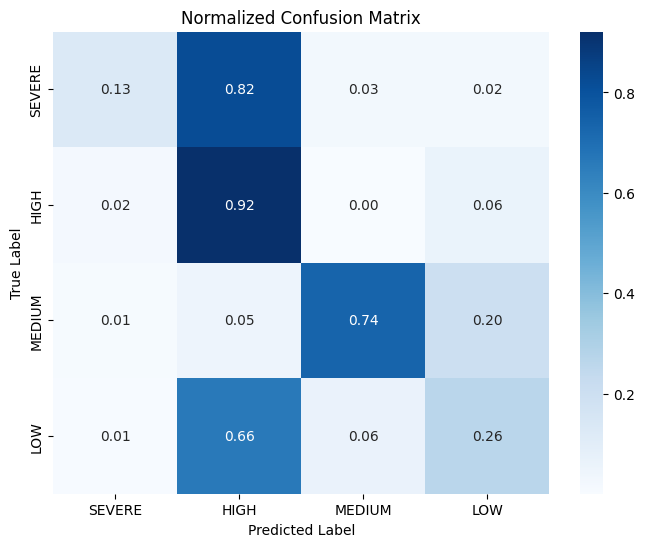

Interpretation: Each cell [i, j] shows the percentage of true class 'i' that were predicted as class 'j'.


In [13]:
print("\n--- Confusion Matrix Plot ---")

REVERSE_SEVERITY_MAP = {v: k for k, v in SEVERITY_MAP.items()}
class_names = [REVERSE_SEVERITY_MAP[i] for i in sorted(REVERSE_SEVERITY_MAP.keys())]

cm = confusion_matrix(targets, preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] 

plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues", 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Normalized Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("Interpretation: Each cell [i, j] shows the percentage of true class 'i' that were predicted as class 'j'.")


--- Loss Curve Plot ---


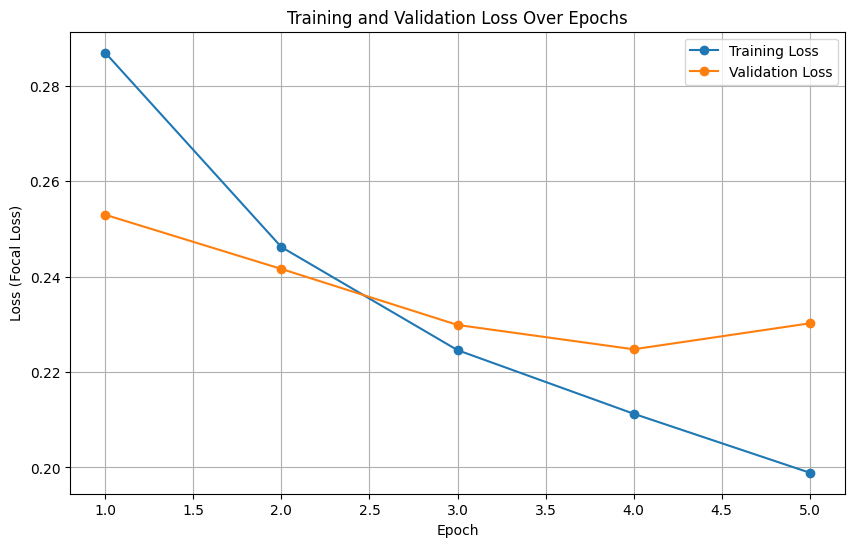

In [14]:
print("\n--- Loss Curve Plot ---")

if train_losses_history and val_losses_history:
    epochs = range(1, Config.EPOCHS + 1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses_history, 'o-', label='Training Loss')
    plt.plot(epochs, val_losses_history, 'o-', label='Validation Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (Focal Loss)')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Loss history lists are empty. Please re-run the training loop after modifying it to save losses.")